"""
Notebook: Canada Crop Yield (1908–2024) – Exploratory Analysis

This notebook:
- Loads the AAA.csv dataset from data/raw
- Cleans the GEO (region) column by removing aggregate regions (Canada, East, West, etc.)
- Explores unique crop types and provinces
- Aggregates crop yields by crop and province
- Visualizes the distribution of crops using bar charts and pie charts


"""


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Use relative path
df = pd.read_csv("../data/raw/AAA.csv", encoding="latin-1")

df.head()


C:\Users\ytjay\AppData\Local\Temp\ipykernel_3260\956310989.py:9: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/AAA.csv", encoding="latin-1")


,"ï»¿""REF_DATE""",GEO,DGUID,Harvest disposition,Type of crop,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1908,Canada,2016A000011124,Seeded area (acres),Barley,Acres,28,units,0,v46457,1.1.6,1745700.0,NaN,NaN,NaN,0
1,1908,Canada,2016A000011124,Seeded area (acres),"Beans, all dry (white and coloured)",Acres,28,units,0,v54532262,1.1.39,59900.0,NaN,NaN,NaN,0
2,1908,Canada,2016A000011124,Seeded area (acres),"Beans, dry white",Acres,28,units,0,v54532263,1.1.40,NaN,..,NaN,NaN,0
3,1908,Canada,2016A000011124,Seeded area (acres),"Beans, dry coloured",Acres,28,units,0,v54532264,1.1.41,NaN,..,NaN,NaN,0
4,1908,Canada,2016A000011124,Seeded area (acres),Borage seed,Acres,28,units,0,v54529215,1.1.37,NaN,..,NaN,t,0


In [2]:
df

,"ï»¿""REF_DATE""",GEO,DGUID,Harvest disposition,Type of crop,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1908,Canada,2016A000011124,Seeded area (acres),Barley,Acres,28,units,0,v46457,1.1.6,1745700.0,NaN,NaN,NaN,0
1,1908,Canada,2016A000011124,Seeded area (acres),"Beans, all dry (white and coloured)",Acres,28,units,0,v54532262,1.1.39,59900.0,NaN,NaN,NaN,0
2,1908,Canada,2016A000011124,Seeded area (acres),"Beans, dry white",Acres,28,units,0,v54532263,1.1.40,NaN,..,NaN,NaN,0
3,1908,Canada,2016A000011124,Seeded area (acres),"Beans, dry coloured",Acres,28,units,0,v54532264,1.1.41,NaN,..,NaN,NaN,0
4,1908,Canada,2016A000011124,Seeded area (acres),Borage seed,Acres,28,units,0,v54529215,1.1.37,NaN,..,NaN,t,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
382568,2024,Alberta,2016A000248,Seeded area (hectares),"Wheat, winter seeded in fall",Hectares,149,units,0,v115114493,11.16.44,76600.0,NaN,NaN,NaN,0
382569,2024,British Columbia,2016A000259,Seeded area (acres),"Rye, fall seeded in previous fall",Acres,28,units,0,v62700998,12.1.43,11800.0,NaN,NaN,NaN,0
382570,2024,British Columbia,2016A000259,Seeded area (acres),"Wheat, winter seeded in fall",Acres,28,units,0,v65584714,12.1.44,22000.0,NaN,NaN,NaN,0
382571,2024,British Columbia,2016A000259,Seeded area (hectares),"Rye, fall seeded in previous fall",Hectares,149,units,0,v115114879,12.16.43,4800.0,NaN,NaN,NaN,0


In [ ]:
df.info()

In [3]:
df.describe()

,"ï»¿""REF_DATE""",UOM_ID,SCALAR_ID,VALUE,DECIMALS
count,382573.000000,382573.000000,382573.000000,1.943200e+05,382573.000000
mean,1965.085212,119.091376,0.391847,6.490195e+05,0.174309
std,33.563387,75.467994,1.010164,2.614531e+06,0.485602
min,1908.000000,28.000000,0.000000,0.000000e+00,0.000000
25%,1936.000000,42.000000,0.000000,5.800000e+01,0.000000
50%,1965.000000,149.000000,0.000000,4.000000e+03,0.000000
75%,1994.000000,193.000000,0.000000,9.500000e+04,0.000000
max,2024.000000,293.000000,3.000000,3.758910e+07,2.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382573 entries, 0 to 382572
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ï»¿"REF_DATE"        382573 non-null  int64  
 1   GEO                  382573 non-null  object 
 2   DGUID                321182 non-null  object 
 3   Harvest disposition  382573 non-null  object 
 4   Type of crop         382573 non-null  object 
 5   UOM                  382573 non-null  object 
 6   UOM_ID               382573 non-null  int64  
 7   SCALAR_FACTOR        382573 non-null  object 
 8   SCALAR_ID            382573 non-null  int64  
 9   VECTOR               382573 non-null  object 
 10  COORDINATE           382573 non-null  object 
 11  VALUE                194320 non-null  float64
 12  STATUS               188253 non-null  object 
 13  SYMBOL               171 non-null     object 
 14  TERMINATED           141619 non-null  object 
 15  DECIMALS         

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

ï»¿"REF_DATE"               0
GEO                         0
DGUID                   61391
Harvest disposition         0
Type of crop                0
UOM                         0
UOM_ID                      0
SCALAR_FACTOR               0
SCALAR_ID                   0
VECTOR                      0
COORDINATE                  0
VALUE                  188253
STATUS                 194320
SYMBOL                 382402
TERMINATED             240954
DECIMALS                    0
dtype: int64

In [7]:
GEO=list(df['GEO'].unique())
GEO

['Canada',
 'Newfoundland and Labrador',
 'Maritime provinces',
 'Prince Edward Island',
 'Nova Scotia',
 'New Brunswick',
 'Quebec',
 'Ontario',
 'East',
 'Prairie provinces',
 'Manitoba',
 'Saskatchewan',
 'Alberta',
 'British Columbia',
 'West']

In [8]:
len(GEO)
values_to_delete = ['Canada', 'East', 'West','Maritime provinces','Prairie provinces']  # Replace with the specific values you want to delete

# Create a boolean mask for rows that do not contain the specified values
mask = ~df['GEO'].isin(values_to_delete)

# Apply the mask to keep only the rows you want to keep
df = df[mask]

# Reset index if needed
df = df.reset_index(drop=True)

In [9]:
Crops=list(df['Type of crop'].unique())
Crops

['Tame hay',
 'Barley',
 'Buckwheat',
 'Corn for grain',
 'Corn for silage',
 'Mixed grains',
 'Oats',
 'Peas, dry',
 'Rye, all',
 'Rye, fall remaining',
 'Rye, fall seeded in previous fall',
 'Soybeans',
 'Wheat, all',
 'Wheat, all including winter wheat remaining',
 'Wheat, spring',
 'Wheat, winter remaining',
 'Wheat, winter seeded in fall',
 'Wheat, all excluding durum wheat',
 'Beans, all dry (white and coloured)',
 'Canola (rapeseed)',
 'Beans, dry white',
 'Beans, dry coloured',
 'Rye, all including fall rye remaining',
 'Sugar beets',
 'Flaxseed',
 'Canary seed',
 'Faba beans',
 'Lentils',
 'Mustard seed',
 'Rye, spring',
 'Safflower',
 'Summerfallow',
 'Sunflower seed',
 'Triticale',
 'Wheat, durum',
 'Wheat, Canada Western Extra Strong (CWES)',
 'Wheat, Canada Western Red Spring (CWRS)',
 'Wheat, Canada Prairie Spring Red (CPSR) and Canada Prairie Spring White (CPSW)',
 'Wheat, Canada Western Soft White Spring (CWSWS)',
 'Wheat, other spring',
 'Borage seed',
 'Caraway seed',

In [10]:
len(Crops)

49

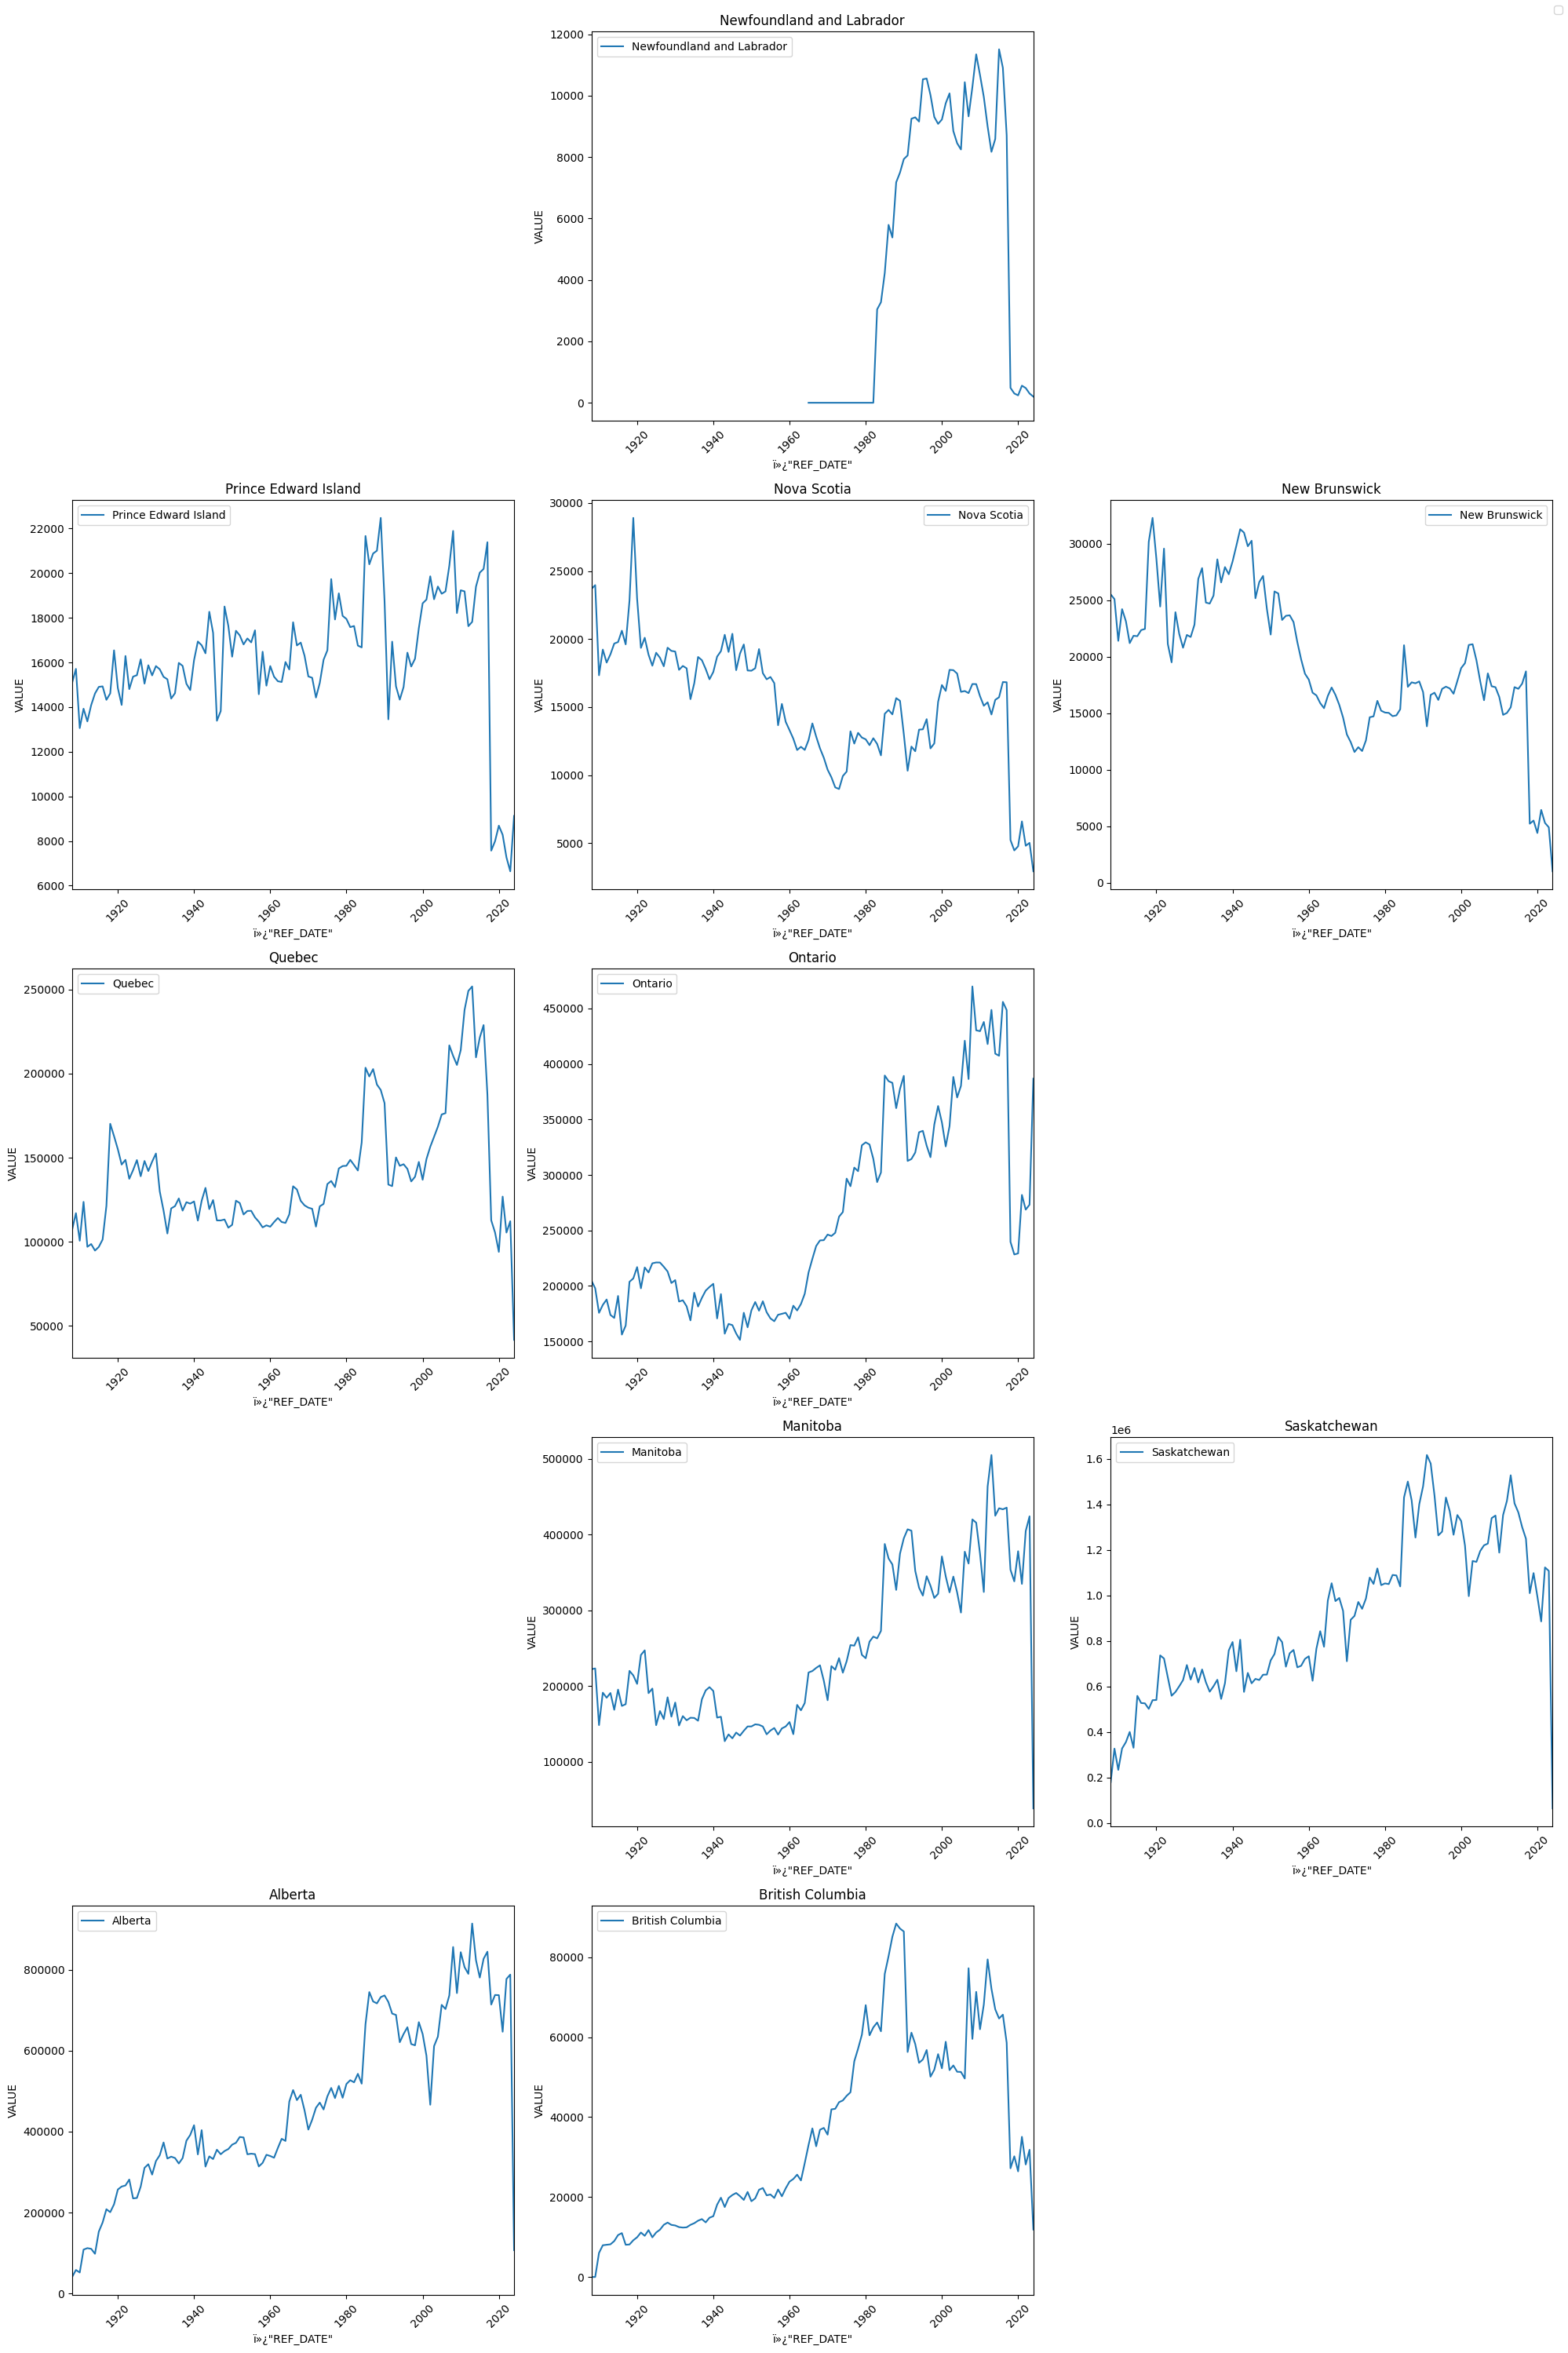

In [11]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(20, 30))

for i, geo_region in enumerate(GEO):
    row = i // 3
    col = i % 3
    region_df = df[df['GEO'] == geo_region]
    mean_by_date = region_df.groupby('ï»¿"REF_DATE"')['VALUE'].mean().reset_index()

    # Check if the DataFrame is not empty
    if not mean_by_date.empty:
        sns.lineplot(data=mean_by_date, x='ï»¿"REF_DATE"', y='VALUE', ax=axes[row, col], label=geo_region)

        axes[row, col].set_title(geo_region)
        axes[row, col].set_xlim(1908, 2024)  # Use set_xlim on the specific axis
        axes[row, col].tick_params(axis='x', rotation=45)  # Rotate x-axis labels for better readability
    else:
        # If DataFrame is empty, remove the subplot
        fig.delaxes(axes[row, col])

# Adjust layout for better readability
plt.tight_layout()

# Add a legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

# Show the plot
plt.show()


In [12]:
Crop_Province_Group=df.groupby(by=['Type of crop','GEO']).agg({'VALUE':'mean'}).reset_index()
Crop_Province_Group

,Type of crop,GEO,VALUE
0,Barley,Alberta,1.192628e+06
1,Barley,British Columbia,2.771068e+04
2,Barley,Manitoba,4.002800e+05
3,Barley,New Brunswick,6.210617e+03
4,Barley,Newfoundland and Labrador,2.000000e+01
...,...,...,...
451,"Wheat, winter seeded in fall",Nova Scotia,3.582671e+03
452,"Wheat, winter seeded in fall",Ontario,4.720520e+05
453,"Wheat, winter seeded in fall",Prince Edward Island,5.358705e+03
454,"Wheat, winter seeded in fall",Quebec,1.554310e+04


C:\Users\ytjay\AppData\Local\Temp\ipykernel_3260\3448739038.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crop_df, x='GEO', y='VALUE', ax=axes[row, col], palette='viridis')
C:\Users\ytjay\AppData\Local\Temp\ipykernel_3260\3448739038.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crop_df, x='GEO', y='VALUE', ax=axes[row, col], palette='viridis')
C:\Users\ytjay\AppData\Local\Temp\ipykernel_3260\3448739038.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crop_df, x='GEO', y='VALUE', ax=axes[row, col], palette='vi

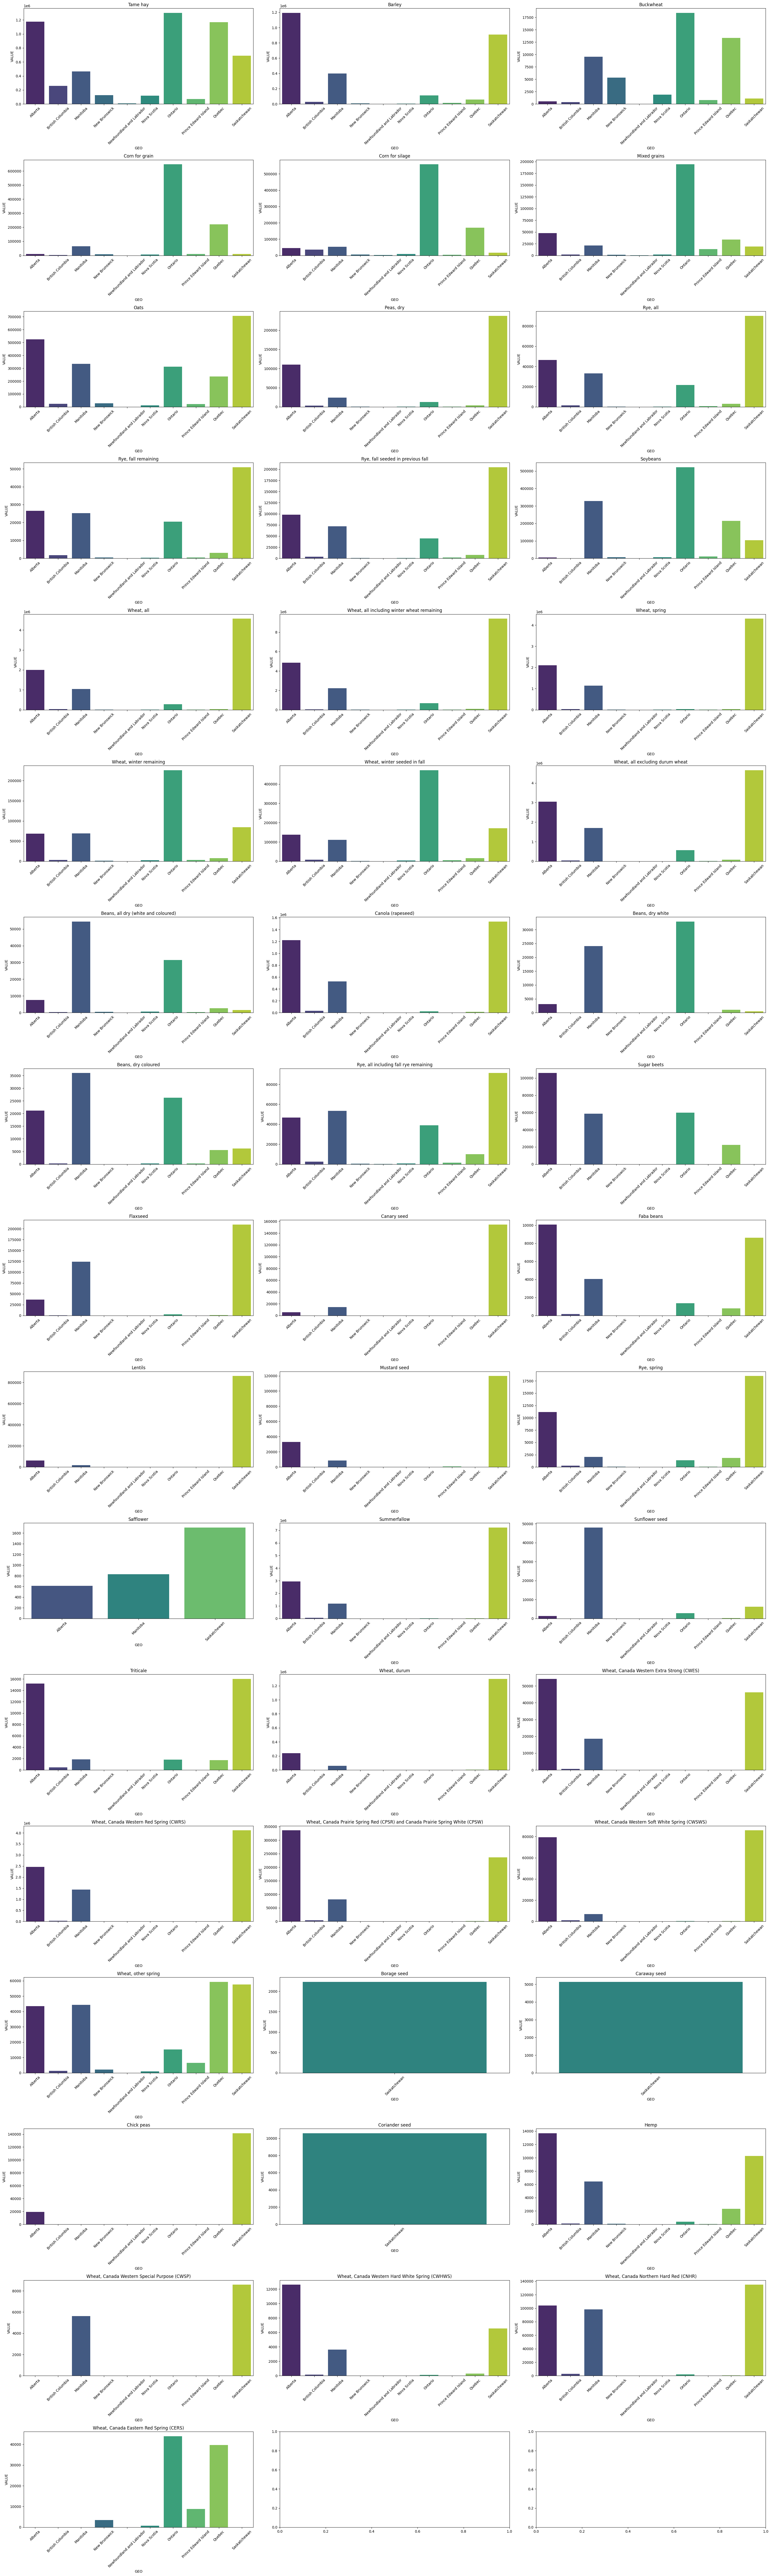

In [13]:
fig, axes = plt.subplots(nrows=17, ncols=3, figsize=(30, 100))

for i, crop_type in enumerate(Crops):
    row = i // 3
    col = i % 3
    crop_df = Crop_Province_Group[Crop_Province_Group['Type of crop'] == crop_type]

    # Check if the DataFrame is not empty
    if not crop_df.empty:
        sns.barplot(data=crop_df, x='GEO', y='VALUE', ax=axes[row, col], palette='viridis')
        axes[row, col].set_title(crop_type)
        axes[row, col].tick_params(axis='x', rotation=45)  # Adjust rotation based on your needs
    else:
        # If DataFrame is empty, remove the subplot
        fig.delaxes(axes[row, col])

# Adjust layout for better readability
plt.tight_layout()

# Show the plot
plt.show()


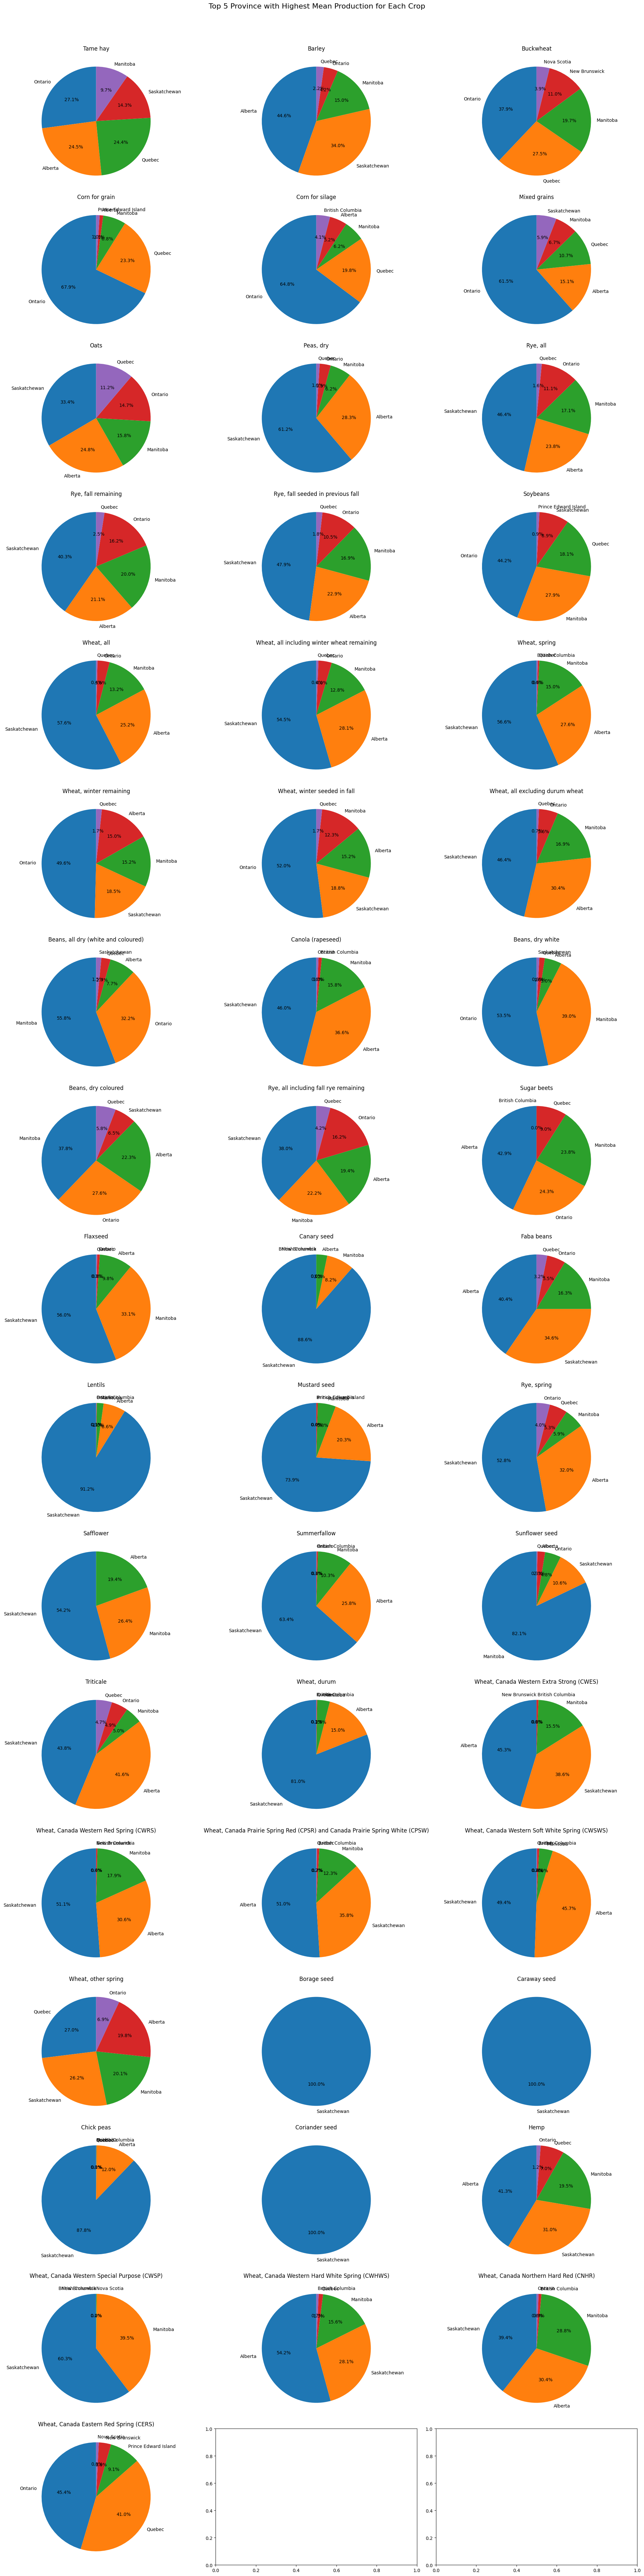

In [14]:
Crop_Province_Group2 = df.groupby(by=['Type of crop', 'GEO']).agg({'VALUE': 'mean'}).reset_index()
fig, axes = plt.subplots(nrows=17, ncols=3, figsize=(20, 80))

for i, crop_type in enumerate(Crops):
    row = i // 3
    col = i % 3
    top_states = Crop_Province_Group2[Crop_Province_Group2['Type of crop'] == crop_type].nlargest(5, 'VALUE')

    # Check if the DataFrame is not empty
    if not top_states.empty:
        ax = axes[row, col]
        ax.pie(top_states['VALUE'], labels=top_states['GEO'], autopct='%1.1f%%', startangle=90)
        ax.set_aspect('equal')
        ax.set_title(crop_type)
    else:
        # If DataFrame is empty, remove the subplot
        fig.delaxes(axes[row, col])

# Add an overall title
plt.suptitle("Top 5 Province with Highest Mean Production for Each Crop", fontsize=16)

# Adjust layout for better readability
plt.tight_layout(rect=[0, 0, 1, 0.97])  # Adjust the rectangle to leave space for the suptitle

# Show the plot
plt.show()


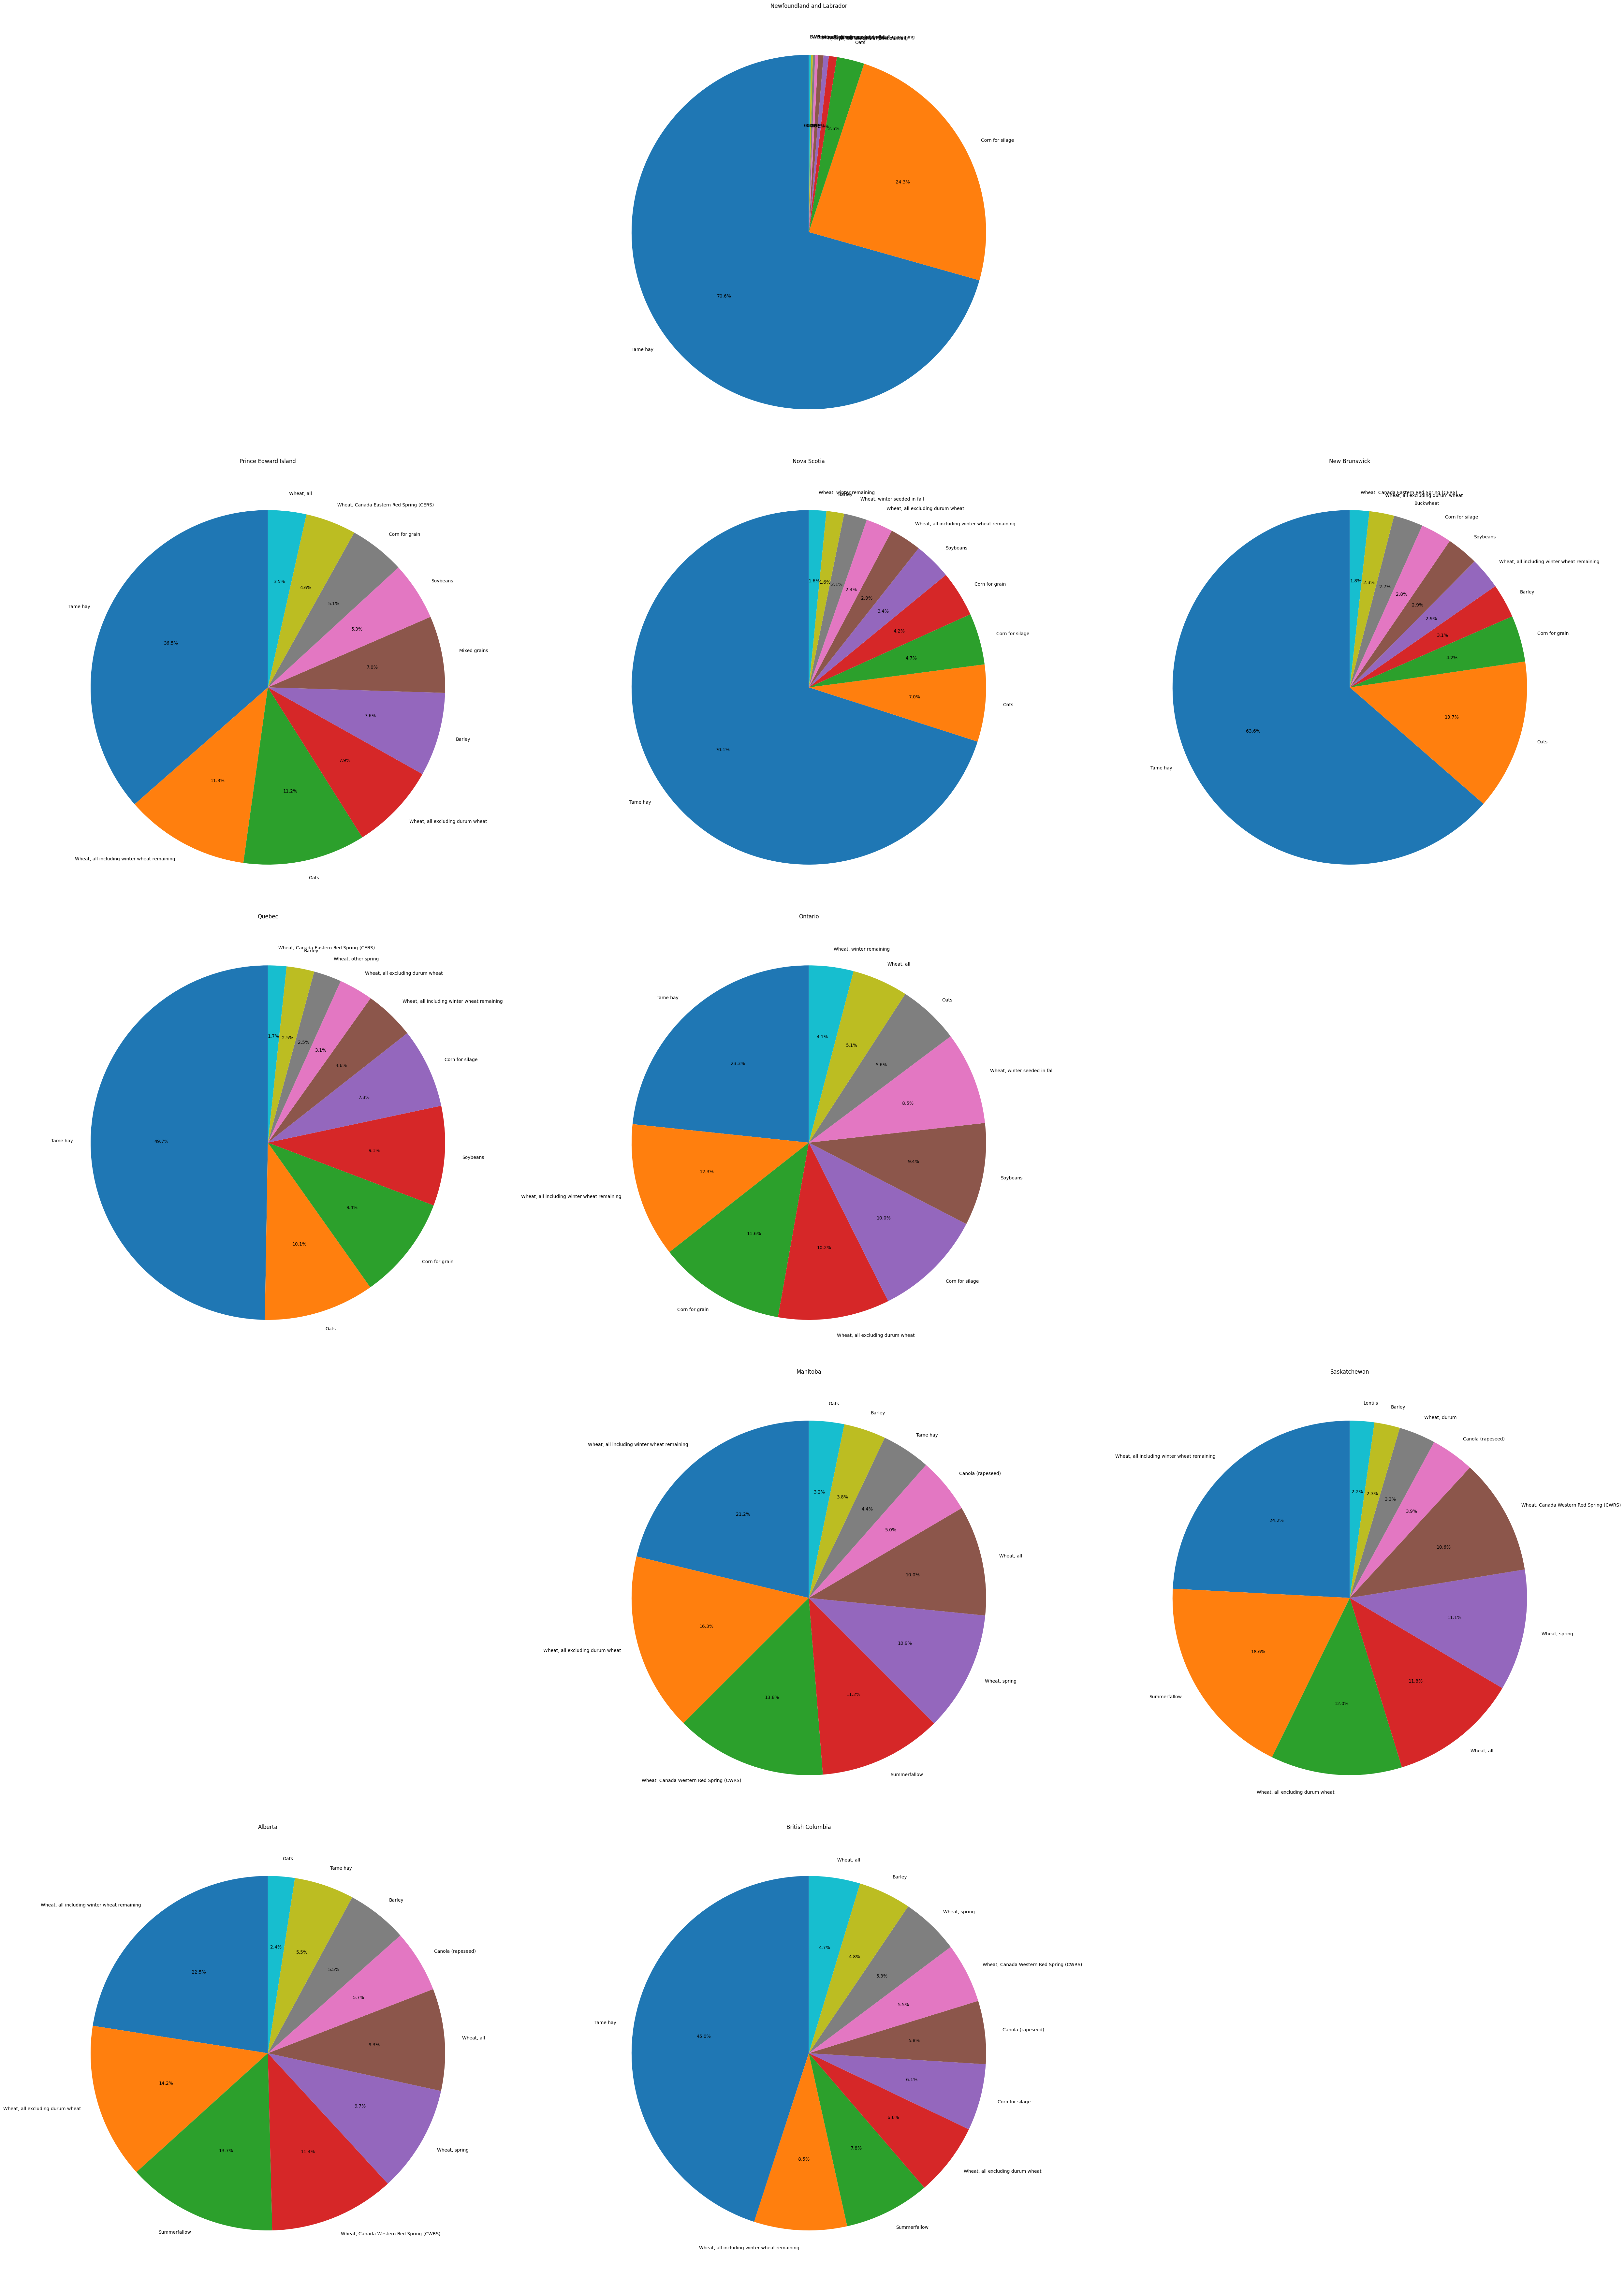

: 

In [ ]:
Crop_Province_Group3 = df.groupby(by=['Type of crop', 'GEO']).agg({'VALUE': 'mean'}).reset_index()
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(50, 70))

for i, province in enumerate(GEO):
    row = i // 3
    col = i % 3
    x = Crop_Province_Group3[Crop_Province_Group3['GEO'] == province].sort_values(by='VALUE', ascending=False).head(10)

    # Check if the DataFrame is not empty
    if not x.empty:
        ax = axes[row, col]
        ax.pie(x['VALUE'], labels=x['Type of crop'], autopct='%1.1f%%', startangle=90)
        ax.set_aspect('equal') 
        ax.set_title(province)
    else:
        # If DataFrame is empty, remove the subplot
        plt.delaxes(axes[row, col])

# Adjust layout for better readability
plt.tight_layout()

# Show the plot
plt.show()
